In [1]:
#Importing libraries
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import ast
import seaborn as sns

#Loading data
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset['train'].to_pandas()

#Data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

d:\Anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Filter the dataset for jobs located in India and create a deep copy to avoid SettingWithCopy warnings
df_ind = df[df['job_country'] == 'India'].copy()

# Define a function to unify salary data into a single annual figure
def combine_salaries(row):
    if pd.notna(row['salary_year_avg']):
        return row['salary_year_avg']
    
    # Check for hourly salary and convert to annual (assuming 40 hours/week, 52 weeks/year)
    # NOTE: Changed your 'elif' from 'salary_year_avg' to 'salary_hour_avg' to fix the logic
    elif pd.notna(row['salary_hour_avg']):
        return row['salary_hour_avg'] * 52 * 40
    else:
        return None

# Apply the conversion function across every row (axis=1) to create the new combined salary column
# Note: Use df_ind.apply here to ensure you are mapping against the filtered India data
df_ind['yearly_salary_combined'] = df_ind.apply(combine_salaries, axis=1)

# Remove all rows where salary information is missing to ensure a clean dataset for analysis/plotting
df_ind = df_ind.dropna(subset=['yearly_salary_combined'])

# Display the final cleaned DataFrame
df_ind

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,yearly_salary_combined
1209,Machine Learning Engineer,Computer Vision Developer (R&D),"Bengaluru, Karnataka, India",via Ai-Jobs.net,Full-time,False,India,2023-02-18 13:12:30,False,False,India,year,79200.0,NaN,Bosch Group,"[python, opencv, tensorflow, pytorch, keras, m...","{'libraries': ['opencv', 'tensorflow', 'pytorc...",79200.0
2022,Data Engineer,Data Engineer - SQL (Power BI),India,via Ai-Jobs.net,Full-time,False,India,2023-10-31 13:09:54,False,False,India,year,156500.0,NaN,Gartner,"[java, t-sql, sql, azure, power bi, dax, notion]","{'analyst_tools': ['power bi', 'dax'], 'async'...",156500.0
2785,Data Engineer,Staff Software Engineer - Data Engineering (Ja...,"Bengaluru, Karnataka, India",via Ai-Jobs.net,Full-time,False,India,2023-05-26 13:13:28,False,False,India,year,147500.0,NaN,Zscaler,"[java, nosql, neo4j, redshift, aws, spring, sp...","{'analyst_tools': ['excel'], 'cloud': ['redshi...",147500.0
3190,Senior Data Engineer,Senior Big Data DevOps & Deployment Engineer,"Bengaluru, Karnataka, India",via Ai-Jobs.net,Full-time,False,India,2023-07-07 13:14:21,False,False,India,year,79200.0,NaN,ServiceNow,"[sql, perl, bash, groovy, python, shell, redis...","{'analyst_tools': ['tableau'], 'cloud': ['azur...",79200.0
3930,Data Scientist,Lead Data Scientist,"Bengaluru, Karnataka, India",via Ai-Jobs.net,Full-time,False,India,2023-12-12 13:27:33,False,False,India,year,114516.0,NaN,Boeing,"[python, r, c++, tensorflow, tableau]","{'analyst_tools': ['tableau'], 'libraries': ['...",114516.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
783733,Senior Data Scientist,Senior Data Scientist,"Bengaluru, Karnataka, India",via Ai-Jobs.net,Full-time,False,India,2023-06-27 06:12:11,False,False,India,year,157500.0,NaN,Publicis Groupe,"[aws, spark, tableau, cognos, excel, powerpoin...","{'analyst_tools': ['tableau', 'cognos', 'excel...",157500.0
784033,Data Analyst,Recruitment Data Analyst,"Mumbai, Maharashtra, India",via Ai-Jobs.net,Full-time,False,India,2023-06-07 06:10:15,False,False,India,year,111175.0,NaN,Framestore,"[power bi, tableau]","{'analyst_tools': ['power bi', 'tableau']}",111175.0
784768,Data Scientist,SR. DATA SCIENTIST,"Bengaluru, Karnataka, India",via Ai-Jobs.net,Full-time,False,India,2023-01-03 06:25:25,False,False,India,year,157500.0,NaN,Optiv,"[r, python, sql, databricks, power bi]","{'analyst_tools': ['power bi'], 'cloud': ['dat...",157500.0
785395,Data Engineer,Senior Consultant - Tech Consulting -Azure Dat...,India,via Ai-Jobs.net,Full-time,False,India,2023-12-19 06:10:41,False,False,India,year,64800.0,NaN,EY,"[sql, python, azure, databricks, spark, power ...","{'analyst_tools': ['power bi', 'tableau', 'qli...",64800.0


In [3]:
# Group by job title and calculate both the total number of postings (count) and the middle salary (median)
# Sort the results so the highest-paying roles appear first
# Keep only the top 6 entries for a focused visualization
df_ind_jobs = df_ind.groupby('job_title_short')['yearly_salary_combined'].agg(['count', 'median']).sort_values(by='median', ascending=False).head(6)

df_ind_jobs

,count,median
job_title_short,,
Senior Data Scientist,33,149653.0
Senior Data Engineer,57,147500.0
Data Engineer,170,147500.0
Data Scientist,93,113500.0
Senior Data Analyst,27,111175.0
Data Analyst,97,98500.0


In [4]:
# Create a filtered DataFrame by checking if 'job_title_short' is in the top 6 high-paying roles list
# We use .index because df_ind_jobs has the job titles as its index
df_ind_salary = df_ind[df_ind['job_title_short'].isin(df_ind_jobs.index)]

# Display the resulting DataFrame containing only relevant high-paying role data
df_ind_salary

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,yearly_salary_combined
2022,Data Engineer,Data Engineer - SQL (Power BI),India,via Ai-Jobs.net,Full-time,False,India,2023-10-31 13:09:54,False,False,India,year,156500.0,NaN,Gartner,"[java, t-sql, sql, azure, power bi, dax, notion]","{'analyst_tools': ['power bi', 'dax'], 'async'...",156500.0
2785,Data Engineer,Staff Software Engineer - Data Engineering (Ja...,"Bengaluru, Karnataka, India",via Ai-Jobs.net,Full-time,False,India,2023-05-26 13:13:28,False,False,India,year,147500.0,NaN,Zscaler,"[java, nosql, neo4j, redshift, aws, spring, sp...","{'analyst_tools': ['excel'], 'cloud': ['redshi...",147500.0
3190,Senior Data Engineer,Senior Big Data DevOps & Deployment Engineer,"Bengaluru, Karnataka, India",via Ai-Jobs.net,Full-time,False,India,2023-07-07 13:14:21,False,False,India,year,79200.0,NaN,ServiceNow,"[sql, perl, bash, groovy, python, shell, redis...","{'analyst_tools': ['tableau'], 'cloud': ['azur...",79200.0
3930,Data Scientist,Lead Data Scientist,"Bengaluru, Karnataka, India",via Ai-Jobs.net,Full-time,False,India,2023-12-12 13:27:33,False,False,India,year,114516.0,NaN,Boeing,"[python, r, c++, tensorflow, tableau]","{'analyst_tools': ['tableau'], 'libraries': ['...",114516.0
7946,Data Engineer,Data Engineering Manager,"Mysuru, Karnataka, India",via Ai-Jobs.net,Full-time,False,India,2023-07-28 13:10:54,False,False,India,year,147500.0,NaN,66degrees,"[sql, gcp, bigquery]","{'cloud': ['gcp', 'bigquery'], 'programming': ...",147500.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
783733,Senior Data Scientist,Senior Data Scientist,"Bengaluru, Karnataka, India",via Ai-Jobs.net,Full-time,False,India,2023-06-27 06:12:11,False,False,India,year,157500.0,NaN,Publicis Groupe,"[aws, spark, tableau, cognos, excel, powerpoin...","{'analyst_tools': ['tableau', 'cognos', 'excel...",157500.0
784033,Data Analyst,Recruitment Data Analyst,"Mumbai, Maharashtra, India",via Ai-Jobs.net,Full-time,False,India,2023-06-07 06:10:15,False,False,India,year,111175.0,NaN,Framestore,"[power bi, tableau]","{'analyst_tools': ['power bi', 'tableau']}",111175.0
784768,Data Scientist,SR. DATA SCIENTIST,"Bengaluru, Karnataka, India",via Ai-Jobs.net,Full-time,False,India,2023-01-03 06:25:25,False,False,India,year,157500.0,NaN,Optiv,"[r, python, sql, databricks, power bi]","{'analyst_tools': ['power bi'], 'cloud': ['dat...",157500.0
785395,Data Engineer,Senior Consultant - Tech Consulting -Azure Dat...,India,via Ai-Jobs.net,Full-time,False,India,2023-12-19 06:10:41,False,False,India,year,64800.0,NaN,EY,"[sql, python, azure, databricks, spark, power ...","{'analyst_tools': ['power bi', 'tableau', 'qli...",64800.0


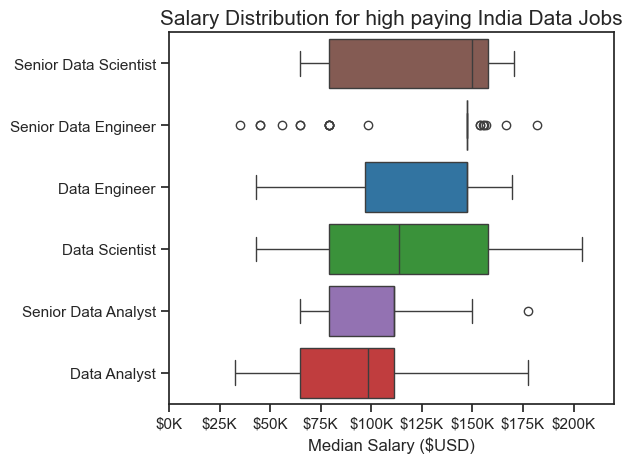

In [5]:
# 1. Set the background theme for a modern look
sns.set_theme(style='ticks')

# 2. Create the boxplot to visualize salary distributions
sns.boxplot(
    data=df_ind_salary,
    x='yearly_salary_combined', 
    y='job_title_short', 
    hue='job_title_short', # Colors the boxes based on the job title
    palette='tab10',     # Uses color map (perceptually uniform)
    legend=False,          # Removes the redundant legend since Y-axis labels exist
    order=df_ind_jobs.index # Ensures roles are sorted by median salary as defined earlier
)

# 3. Get the current axes to apply specific formatting
ax = plt.gca()

# Apply custom formatting to the X-axis using a lambda function
# This converts raw numbers (100000) to human-readable strings ($100K)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos : f'${int(x/1000)}K'))

# Clean up the titles: boxplot() adds a messy default 'suptitle' we want to remove
plt.title('Salary Distribution for high paying India Data Jobs', fontsize=15)
# Final aesthetic adjustments

plt.ylabel('')      # Removes the redundant 'job_title_short' label on the Y-axis
plt.xlabel('Median Salary ($USD)')      # Removes the redundant 'job_title_short' label on the Y-axis
plt.xlim(0, 220000) # Sets the salary range; helpful if you have extreme outliers
plt.tight_layout() # Optimizes spacing so labels don't get cut off
plt.show()